# Asian options on soft commodities

**Part 3.** Pricing and hedging an option on the *average* price of coffee, cocoa and
sugar futures, with volatility that changes through the year.

Part 1 priced Europeans and Americans on SPX with a PDE solver. This notebook moves to
the instrument commodity buyers actually use, and adds the half of the job that pricing
leaves out - hedging it.

The argument, in order:

1. Measure how soft-commodity volatility moves through the calendar year
2. Build a time-dependent `sigma(t)` from it
3. Price the Asian two ways - Monte Carlo with a control variate, and a moment-matched
   formula - and check them against each other and against an exact geometric price
4. Sell the option and delta hedge it along thousands of simulated paths, and measure
   how well the hedge works
5. Ask what ignoring seasonality costs - in price, and in the hedge

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import log, sqrt, exp
from scipy.special import ndtr as normal_cdf      # vectorised, unlike math.erf

plt.rcParams.update({'figure.figsize': (11, 5), 'axes.grid': True, 'grid.alpha': 0.3,
                     'font.size': 10, 'axes.spines.top': False, 'axes.spines.right': False})

COLOURS = {'coffee': '#6b3e26', 'cocoa': '#c0392b', 'sugar': '#2e86c1'}

## 1. The data

Daily settlement prices for the three ICE softs futures - coffee (`KC=F`), cocoa
(`CC=F`) and sugar No. 11 (`SB=F`) - from Yahoo Finance, 2005 to 2025. The download is
cached in `data/` so the notebook runs offline after the first time.

These are **continuous front-month** series: Yahoo splices one contract onto the next as
each expires. That is fine for measuring how volatile the market is in each month of the
year. It is not fine for everything, and section 2 shows exactly where it breaks.

In [2]:
CACHE = 'data/softs_futures.csv'
TICKERS = {'coffee': 'KC=F', 'cocoa': 'CC=F', 'sugar': 'SB=F'}

if os.path.exists(CACHE):
    prices = pd.read_csv(CACHE, index_col=0, parse_dates=True)
else:
    import yfinance as yf
    raw = yf.download(list(TICKERS.values()), start='2005-01-01', end='2026-01-01',
                      progress=False, auto_adjust=False)['Close']
    prices = raw.rename(columns={v: k for k, v in TICKERS.items()})[list(TICKERS)]
    os.makedirs('data', exist_ok=True)
    prices.to_csv(CACHE)

prices = prices.dropna()
returns = np.log(prices).diff().dropna()

print(f"{len(prices)} trading days, {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"days with a move over 8%: {(returns.abs() > 0.08).sum().to_dict()}")

5277 trading days, 2005-01-03 to 2025-12-31
days with a move over 8%: {'coffee': 13, 'cocoa': 33, 'sugar': 19}


The handful of very large daily moves are a mix of real events and contract rolls, where
the series jumps from one delivery month to the next. They are few enough that they do
not move a monthly volatility estimate, so they are kept rather than guessed at.

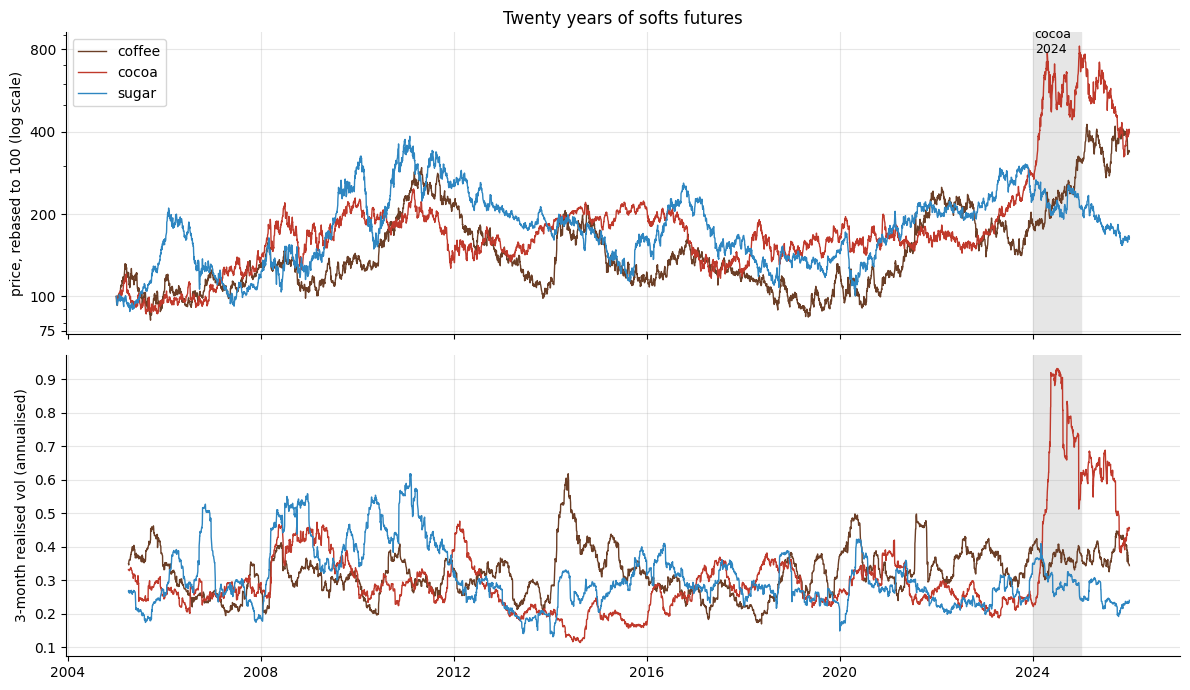

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for name in prices:
    rebased = prices[name]/prices[name].iloc[0]*100
    axes[0].plot(rebased, color=COLOURS[name], lw=1, label=name)
    rolling_vol = returns[name].rolling(63).std()*sqrt(252)
    axes[1].plot(rolling_vol, color=COLOURS[name], lw=1)

for ax in axes:
    ax.axvspan(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'), color='0.9', zorder=0)
axes[0].text(pd.Timestamp('2024-01-15'), axes[0].get_ylim()[1]*0.9, 'cocoa\n2024', fontsize=9)

axes[0].set_yscale('log')
axes[0].set_yticks([75, 100, 200, 400, 800])
axes[0].get_yaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
axes[0].set_ylabel('price, rebased to 100 (log scale)')
axes[0].legend(loc='upper left')
axes[1].set_ylabel('3-month realised vol (annualised)')
axes[0].set_title('Twenty years of softs futures')
plt.tight_layout()
plt.show()

The cocoa spike in 2024 is the dominant feature: West African crops failed two seasons
running and the price roughly tripled in months, with volatility to match. Keep it in
mind - it is a reminder that the *level* of volatility can change far more than any
seasonal pattern does.

## 2. Volatility through the year

The question: is a soft commodity more volatile in some months than others?

There is a physical reason to expect it. Coffee is exposed to Brazilian frost in the
southern winter (roughly June to August). Sugar follows the Brazilian harvest, which runs
from about April to November. Cocoa follows the West African main crop from October.

**The trap:** a plain "volatility by month" calculation is dominated by whichever years
were wild. 2024 cocoa would swamp everything. So each return is first divided by its own
year's volatility. What is left measures the *shape* of the year, independent of how
volatile that year was overall.

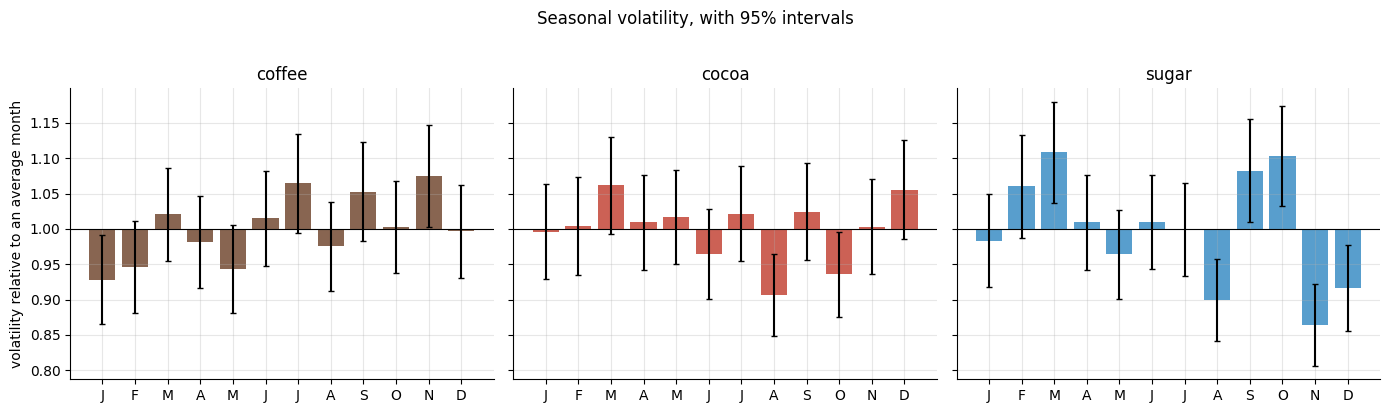

Date      1     2     3     4     5     6     7     8     9     10    11    12
coffee  0.93  0.95  1.02  0.98  0.94  1.01  1.06  0.98  1.05  1.00  1.07  1.00
cocoa   1.00  1.00  1.06  1.01  1.02  0.96  1.02  0.91  1.02  0.94  1.00  1.06
sugar   0.98  1.06  1.11  1.01  0.96  1.01  1.00  0.90  1.08  1.10  0.86  0.92


In [4]:
#each return in units of its own year's volatility, so one wild year cannot dominate
yearly_sd = returns.groupby(returns.index.year).transform('std')
standardised = returns/yearly_sd

by_month = standardised.groupby(standardised.index.month)
seasonal = by_month.std()
seasonal = seasonal/seasonal.mean()                  # average month = 1

#standard error of a standard deviation is about sd/sqrt(2n)
seasonal_se = seasonal/np.sqrt(2*by_month.count())

month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, name in zip(axes, seasonal):
    ax.bar(range(1, 13), seasonal[name] - 1, bottom=1, color=COLOURS[name], alpha=0.8,
           yerr=1.96*seasonal_se[name], capsize=2)
    ax.axhline(1, color='k', lw=0.8)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_names)
    ax.set_title(name)
axes[0].set_ylabel('volatility relative to an average month')
fig.suptitle('Seasonal volatility, with 95% intervals', y=1.02)
plt.tight_layout()
plt.show()

print(seasonal.round(2).T)

The pattern is real but modest - roughly plus or minus ten percent around the average,
with intervals of about plus or minus seven. Coffee runs hottest from July to November,
consistent with frost risk and the Brazilian harvest. Sugar is quiet at the end of the
year. A few months clear the noise; most only just do.

That is worth saying plainly: **seasonality in softs volatility exists, but it is a
second-order effect.** Section 6 measures what it is worth.

### What this data cannot show: the Samuelson effect

Futures volatility is supposed to rise as delivery approaches (Samuelson, 1965) - a
contract a year from delivery barely reacts to today's weather, a contract a month out
reacts to everything. The obvious test is to bin volatility by time to delivery.

In [5]:
DELIVERY_MONTHS = {'coffee': [3, 5, 7, 9, 12], 'cocoa': [3, 5, 7, 9, 12], 'sugar': [3, 5, 7, 10]}

def days_to_next_delivery(dates, months):
    out = []
    for t in dates:
        candidates = [pd.Timestamp(y, m, 1) for y in (t.year, t.year + 1) for m in months]
        out.append((min(c for c in candidates if c > t) - t).days)
    return np.array(out)

buckets = [0, 15, 30, 45, 60, 75, 90, 120]
rows = {}
for name in standardised:
    days = days_to_next_delivery(standardised.index, DELIVERY_MONTHS[name])
    binned = pd.Series(standardised[name].values).groupby(pd.cut(days, buckets)).std()
    rows[name] = (binned/binned.mean()).round(2).values
print("relative volatility by days to the next delivery month")
print(pd.DataFrame(rows, index=[f'{a}-{b}' for a, b in zip(buckets[:-1], buckets[1:])]).T)

C:\Users\kevin\AppData\Local\Temp\ipykernel_26088\3684035239.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = pd.Series(standardised[name].values).groupby(pd.cut(days, buckets)).std()


relative volatility by days to the next delivery month
        0-15  15-30  30-45  45-60  60-75  75-90  90-120
coffee  1.02   1.01   1.00   1.02   1.08   0.99    0.87
cocoa   0.93   0.91   0.90   1.01   0.94   1.05    1.26
sugar   1.16   0.93   0.92   1.02   1.06   0.95    0.96


No consistent rise toward delivery. That is not evidence against Samuelson - it is a
limitation of the data. A continuous front-month series is *always* the contract nearest
delivery, so it only ever covers the last few months of a contract's life, and it jumps
at every roll. Measuring the effect properly needs each contract month's own price
history, which the free source does not provide.

**Decision:** seasonality is fitted from data. The Samuelson effect enters as a clearly
labelled *assumption*, used in section 6 to show how much it would matter if present.

## 3. The contract

A typical average-price option, written as a commodity buyer would use it:

| | |
|---|---|
| written | 1 April 2025 |
| expires | 30 September 2025 |
| averaging | every business day from 1 July to 30 September - the last quarter |
| underlying | a deferred futures contract (December for coffee and cocoa, March for sugar) |
| strike | at the money: the futures price on the day it is written |
| pays | `max(average - strike, 0)` at expiry |

The volatility level is each commodity's realised volatility over the year before
writing. The seasonal factors from section 2 then shape it through the option's life:

    sigma(t) = level x seasonal(month of t)

*Simplification, stated:* the front-month price stands in for the deferred contract's
price on the writing date. For an at-the-money option this changes the numbers, not the
method.

In [6]:
RATE = 0.04                         # flat USD rate, roughly where it was in 2025
DT = 1/252
WRITE, EXPIRY, AVG_START = pd.Timestamp('2025-04-01'), pd.Timestamp('2025-09-30'), pd.Timestamp('2025-07-01')
DELIVERY = {'coffee': pd.Timestamp('2025-12-15'), 'cocoa': pd.Timestamp('2025-12-15'),
            'sugar': pd.Timestamp('2026-03-01')}

dates = pd.bdate_range(WRITE, EXPIRY)               # F is observed on each of these
n_steps = len(dates) - 1
fix_idx = np.where(dates >= AVG_START)[0]           # which observations go into the average
T = n_steps*DT

def contract(name):
    history = returns[name][:WRITE - pd.Timedelta(days=1)]
    level = history.iloc[-252:].std()*sqrt(252)
    F0 = float(prices[name][:WRITE - pd.Timedelta(days=1)].iloc[-1])
    return dict(name=name, F0=F0, K=F0, level=level)

def sigma_seasonal(name, level):
    #one value per step, applying over [t_k, t_k+1]
    return level*seasonal[name].loc[dates[:-1].month].values

def integrated_variance(sig):
    #V[k] = integral of sigma^2 from 0 to t_k - the only thing a European cares about
    return np.concatenate([[0.0], np.cumsum(sig**2*DT)])

for name in seasonal:
    c = contract(name)
    print(f"{name:7s} F0 = {c['F0']:9.2f}   realised vol = {c['level']:.1%}")
print(f"\n{n_steps} steps, {len(fix_idx)} averaging dates, T = {T:.3f} years")

coffee  F0 =    379.75   realised vol = 37.0%
cocoa   F0 =   7902.00   realised vol = 73.1%
sugar   F0 =     18.86   realised vol = 28.4%

130 steps, 66 averaging dates, T = 0.516 years


## 4. Three prices for the same option

**Why the Asian is hard.** Each day's futures price is lognormal. Their *average* is not
lognormal, and has no known distribution, so there is no exact formula for the arithmetic
Asian.

Three routes to a number, each checking the others:

**a) The geometric Asian - exact.** Replace the arithmetic average with the geometric
one. A product of lognormals *is* lognormal, so this has an exact price - even with
time-dependent volatility. With `V_i` the integrated variance up to fixing `i`:

    log G  is normal,  mean = log F0 - mean(V_i)/2,   variance = mean over i,j of V(min(i,j))

It is not the option being sold, but it is very close to it, and that closeness is the
whole trick in (b).

**b) Monte Carlo with a control variate.** Simulate paths, average the payoffs. Plain
Monte Carlo is noisy. But on each path the geometric payoff moves almost in lockstep with
the arithmetic one, and the geometric price is known exactly. So measure how far the
simulated geometric price is from its true value, and correct the arithmetic estimate by
the same amount (scaled by the regression slope between the two). Same paths, far less
noise.

**c) Moment matching (Levy, 1992).** Pretend the average *is* lognormal, with the right
mean and variance. Both moments have closed forms, so this gives a Black-style formula -
approximate, but instant. Instant matters: section 5 needs a delta at every step of
twenty thousand paths, which rules out re-simulating.

In [7]:
#-------- Closed forms -------------------------------------------------------
#-----------------------------------------------------------------------------
def black_call(F, K, var, discount):
    sd = np.sqrt(var)
    d1 = (np.log(F/K) + 0.5*var)/sd
    return discount*(F*normal_cdf(d1) - K*normal_cdf(d1 - sd))


# Exact geometric Asian with time-dependent volatility. Everything about sigma(t)
# enters through V at the fixing dates.
def geometric_asian_call(F0, K, V, fix_idx, discount):
    Vf = V[fix_idx]
    n = len(Vf)
    mean = log(F0) - 0.5*Vf.mean()
    var = np.minimum.outer(Vf, Vf).sum()/n**2       # covariance of log prices is V(min(ti,tj))
    sd = sqrt(var)
    d1 = (mean - log(K) + var)/sd
    return discount*(exp(mean + 0.5*var)*normal_cdf(d1) - K*normal_cdf(d1 - sd))


#-------- Monte Carlo --------------------------------------------------------
#-----------------------------------------------------------------------------
# A futures price has no drift under the pricing measure, so each step is just
# the volatility shock minus the convexity correction.
def simulate_paths(F0, sig, n_paths, seed=0):
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n_paths, len(sig)))
    log_steps = -0.5*sig**2*DT + sig*sqrt(DT)*Z
    paths = F0*np.exp(np.cumsum(log_steps, axis=1))
    return np.hstack([np.full((n_paths, 1), F0), paths])


def asian_monte_carlo(paths, K, fix_idx, discount, geometric_exact):
    fixings = paths[:, fix_idx]
    arithmetic = discount*np.maximum(fixings.mean(axis=1) - K, 0)
    geometric = discount*np.maximum(np.exp(np.log(fixings).mean(axis=1)) - K, 0)

    #the control variate: correct by the known error in the geometric price
    beta = np.cov(arithmetic, geometric)[0, 1]/geometric.var(ddof=1)
    corrected = arithmetic - beta*(geometric - geometric_exact)

    n = len(arithmetic)
    return dict(plain=arithmetic.mean(), plain_se=arithmetic.std(ddof=1)/sqrt(n),
                cv=corrected.mean(), cv_se=corrected.std(ddof=1)/sqrt(n),
                geometric_mc=geometric.mean(), geometric_se=geometric.std(ddof=1)/sqrt(n),
                beta=beta, variance_reduction=arithmetic.var()/corrected.var(),
                arithmetic_payoffs=arithmetic, corrected_payoffs=corrected)

In [8]:
#-------- Moment matching, usable at any point during the option's life -----------
#-----------------------------------------------------------------------------
# Part-way through the averaging period some fixings are already known. Only the
# remaining part of the average is uncertain, so only that part is matched to a
# lognormal - the known part just lowers the effective strike.
#
#   remaining part B:  E[B] = m F / n,   E[B^2] = F^2 sum_ij exp(V(min(ti,tj)) - V_now) / n^2
#
# The ratio E[B^2]/E[B]^2 does not depend on F, so the delta comes out in closed
# form: discount x N(d1) x m/n.
class MomentMatchedAsian:
    def __init__(self, V, fix_idx, K, rate=RATE):
        self.V, self.fix_idx, self.K, self.rate = V, np.asarray(fix_idx), K, rate
        self.n = len(fix_idx)
        self.T = (len(V) - 1)*DT
        Vf = V[self.fix_idx]
        E = np.exp(np.minimum.outer(Vf, Vf))
        #sum of the block E[j:, j:] for every j - the fixings still to come
        self.tail_sums = np.array([E[j:, j:].sum() for j in range(self.n)] + [0.0])

    def price_delta(self, k, F, past_sum):
        F = np.asarray(F, dtype=float)
        past_sum = np.broadcast_to(past_sum, F.shape).astype(float)
        first_future = np.searchsorted(self.fix_idx, k, side='right')
        m = self.n - first_future                    # fixings still to come
        discount = exp(-self.rate*(self.T - k*DT))
        K_eff = self.K - past_sum/self.n             # strike left for the remaining part

        if m == 0:
            return discount*np.maximum(-K_eff, 0), np.zeros_like(F)

        M1 = m*F/self.n
        var = log(self.tail_sums[first_future]*exp(-self.V[k])/m**2)
        sd = sqrt(var)
        certain = K_eff <= 0                         # already locked in the money
        K_safe = np.where(certain, 1.0, K_eff)
        d1 = (np.log(M1/K_safe) + 0.5*var)/sd
        price = np.where(certain, discount*(M1 - K_eff),
                         discount*(M1*normal_cdf(d1) - K_safe*normal_cdf(d1 - sd)))
        delta = np.where(certain, discount*m/self.n, discount*normal_cdf(d1)*m/self.n)
        return price, delta


def european_price_delta(k, F, V, K, rate=RATE):
    remaining_var = V[-1] - V[k]
    discount = exp(-rate*((len(V) - 1) - k)*DT)
    F = np.asarray(F, dtype=float)
    if remaining_var <= 0:
        return discount*np.maximum(F - K, 0), discount*(F > K)
    sd = sqrt(remaining_var)
    d1 = (np.log(F/K) + 0.5*remaining_var)/sd
    return discount*(F*normal_cdf(d1) - K*normal_cdf(d1 - sd)), discount*normal_cdf(d1)

### Coffee first, every check visible

In [9]:
coffee = contract('coffee')
sig = sigma_seasonal('coffee', coffee['level'])
V = integrated_variance(sig)
D = exp(-RATE*T)

geo_exact = geometric_asian_call(coffee['F0'], coffee['K'], V, fix_idx, D)
paths = simulate_paths(coffee['F0'], sig, n_paths=200_000, seed=1)
mc = asian_monte_carlo(paths, coffee['K'], fix_idx, D, geo_exact)
mm = MomentMatchedAsian(V, fix_idx, coffee['K'])
mm_price = float(mm.price_delta(0, coffee['F0'], 0.0)[0])
euro = black_call(coffee['F0'], coffee['K'], V[-1], D)

print(f"coffee, F0 = K = {coffee['F0']:.2f}\n")
print(f"V5  geometric, exact            : {geo_exact:9.4f}")
print(f"    geometric, Monte Carlo      : {mc['geometric_mc']:9.4f} +/- {mc['geometric_se']:.4f}"
      f"   ({(mc['geometric_mc'] - geo_exact)/mc['geometric_se']:+.1f} standard errors)")
print()
print(f"V6  arithmetic, plain MC        : {mc['plain']:9.4f} +/- {mc['plain_se']:.4f}")
print(f"    arithmetic, control variate : {mc['cv']:9.4f} +/- {mc['cv_se']:.4f}")
print(f"    arithmetic, moment matched  : {mm_price:9.4f}   ({(mm_price/mc['cv'] - 1):+.2%} vs MC)")
print()
print(f"    variance reduction factor   : {mc['variance_reduction']:.0f}x"
      f"   (same accuracy with 1/{mc['variance_reduction']:.0f} of the paths)")
print(f"    European, same strike       : {euro:9.4f}")
print(f"    Asian / European            : {mc['cv']/euro:.2f}")

coffee, F0 = K = 379.75

V5  geometric, exact            :   31.3309
    geometric, Monte Carlo      :   31.3633 +/- 0.1180   (+0.3 standard errors)

V6  arithmetic, plain MC        :   31.9847 +/- 0.1195
    arithmetic, control variate :   31.9520 +/- 0.0020
    arithmetic, moment matched  :   31.9686   (+0.05% vs MC)

    variance reduction factor   : 3591x   (same accuracy with 1/3591 of the paths)
    European, same strike       :   39.5502
    Asian / European            : 0.81


Three things to read off that:

- the simulated geometric price lands on the exact one, so the simulation is right
- the control variate collapses the error bar - the variance reduction factor is how many
  times fewer paths it needs for the same accuracy
- moment matching agrees with Monte Carlo closely enough to hedge with, which is its job
  in section 5

The Asian is much cheaper than the European because averaging over three months removes
much of the risk - which is exactly why buyers like it.

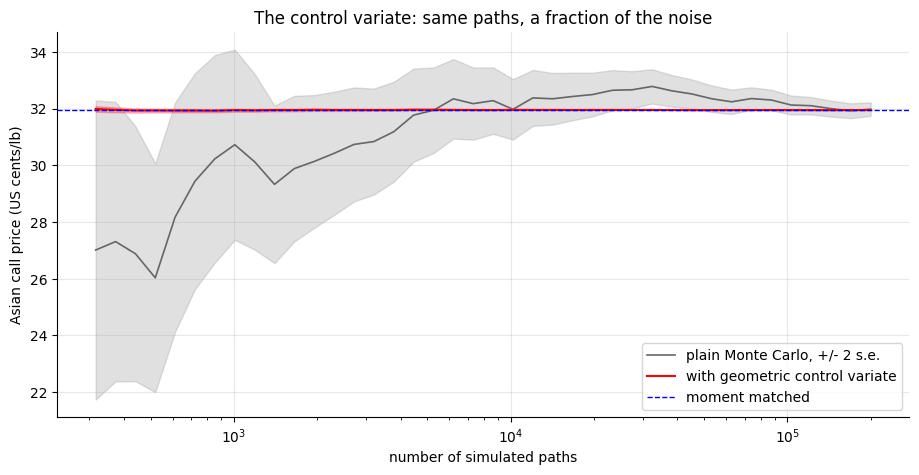

In [10]:
#convergence: running estimate against number of paths, with and without the control variate
checkpoints = np.unique(np.logspace(2.5, np.log10(len(paths)), 40).astype(int))
plain_run = [mc['arithmetic_payoffs'][:n].mean() for n in checkpoints]
plain_band = [2*mc['arithmetic_payoffs'][:n].std()/sqrt(n) for n in checkpoints]
cv_run = [mc['corrected_payoffs'][:n].mean() for n in checkpoints]
cv_band = [2*mc['corrected_payoffs'][:n].std()/sqrt(n) for n in checkpoints]

fig, ax = plt.subplots()
ax.fill_between(checkpoints, np.subtract(plain_run, plain_band), np.add(plain_run, plain_band),
                color='0.6', alpha=0.3)
ax.plot(checkpoints, plain_run, color='0.4', lw=1.2, label='plain Monte Carlo, +/- 2 s.e.')
ax.fill_between(checkpoints, np.subtract(cv_run, cv_band), np.add(cv_run, cv_band),
                color='r', alpha=0.25)
ax.plot(checkpoints, cv_run, 'r-', lw=1.5, label='with geometric control variate')
ax.axhline(mm_price, color='b', ls='--', lw=1, label='moment matched')
ax.set_xscale('log')
ax.set_xlabel('number of simulated paths')
ax.set_ylabel('Asian call price (US cents/lb)')
ax.set_title('The control variate: same paths, a fraction of the noise')
ax.legend()
plt.show()

### All three softs

In [11]:
table = []
for name in seasonal:
    c = contract(name)
    sig_c = sigma_seasonal(name, c['level'])
    V_c = integrated_variance(sig_c)
    geo = geometric_asian_call(c['F0'], c['K'], V_c, fix_idx, D)
    res = asian_monte_carlo(simulate_paths(c['F0'], sig_c, 100_000, seed=2), c['K'], fix_idx, D, geo)
    mm_c = float(MomentMatchedAsian(V_c, fix_idx, c['K']).price_delta(0, c['F0'], 0.0)[0])
    eu = black_call(c['F0'], c['K'], V_c[-1], D)
    table.append(dict(commodity=name, F0=c['F0'], vol=f"{c['level']:.0%}",
                      asian_cv=res['cv'], se=res['cv_se'], moment_matched=mm_c,
                      geometric=geo, european=eu, asian_over_euro=res['cv']/eu,
                      variance_reduction=res['variance_reduction']))
pd.DataFrame(table).set_index('commodity').round(4)

,F0,vol,asian_cv,se,moment_matched,geometric,european,asian_over_euro,variance_reduction
commodity,,,,,,,,,
coffee,379.75,37%,31.9531,0.0028,31.9686,31.3309,39.5502,0.8079,3572.6521
cocoa,7902.00,73%,1308.9503,0.2388,1310.9997,1260.2085,1591.2359,0.8226,1123.6967
sugar,18.86,28%,1.2123,0.0001,1.2126,1.1959,1.4925,0.8123,7209.6876


## 5. Hedging the Asian

Pricing is half the job. Whoever sells the option has to hedge it, and how cheaply and
reliably they can do that is what matters commercially.

**The experiment:**

1. Sell the option at the model price; put the premium in a cash account earning the rate
2. Hold `delta` futures, rebalanced on a schedule (futures cost nothing to enter; their
   daily gains and losses go into the cash account)
3. At expiry pay the option's payoff
4. What is left in the account is the **hedging error** - zero for a perfect hedge

Do it on twenty thousand simulated paths and look at the spread of the error.

**First, check the deltas.** The Monte Carlo delta needs a bumped price. Bumping with
fresh random numbers would bury the delta in noise; using the *same* random numbers for
the bumped and unbumped prices (common random numbers) cancels it. For a futures price
driven by multiplicative shocks, the same random numbers with a bumped start just means
scaling every path - so the bump is free.

In [12]:
#V7: deltas by bumping, with common random numbers
h = 0.005
up, down = paths*(1 + h), paths*(1 - h)

def asian_payoff_mean(p):
    return (D*np.maximum(p[:, fix_idx].mean(axis=1) - coffee['K'], 0)).mean()
def euro_payoff_mean(p):
    return (D*np.maximum(p[:, -1] - coffee['K'], 0)).mean()

bump = 2*h*coffee['F0']
asian_delta_mc = (asian_payoff_mean(up) - asian_payoff_mean(down))/bump
euro_delta_mc = (euro_payoff_mean(up) - euro_payoff_mean(down))/bump
asian_delta_mm = float(mm.price_delta(0, coffee['F0'], 0.0)[1])
euro_delta_exact = float(european_price_delta(0, coffee['F0'], V, coffee['K'])[1])

print(f"V7  European delta: bumped MC {euro_delta_mc:.4f}   exact {euro_delta_exact:.4f}")
print(f"    Asian delta   : bumped MC {asian_delta_mc:.4f}   moment matched {asian_delta_mm:.4f}")

V7  European delta: bumped MC 0.5433   exact 0.5419
    Asian delta   : bumped MC 0.5328   moment matched 0.5319


In [13]:
#-------- The hedging simulation ---------------------------------------------
#-----------------------------------------------------------------------------
# model(k, F, past_sum) -> (price, delta) is the hedger's belief. The paths can
# come from a different volatility - that is how model risk gets measured.
#
# rebalance is either "every n days" or a True/False flag per day, so uneven
# schedules can be tested too. Returns the error per path, and the premium charged.
def hedging_error(paths, model, payoff, rebalance, rate=RATE):
    n_paths, n_obs = paths.shape
    is_fixing = np.zeros(n_obs, dtype=bool)
    is_fixing[fix_idx] = True
    if np.isscalar(rebalance):
        rebalance = np.arange(n_obs) % rebalance == 0

    past_sum = paths[:, 0]*is_fixing[0]
    price0, delta = model(0, paths[:, 0], past_sum)
    cash = np.array(price0, dtype=float)

    for k in range(n_obs - 1):
        if rebalance[k]:
            _, delta = model(k, paths[:, k], past_sum)
        cash = cash*exp(rate*DT) + delta*(paths[:, k + 1] - paths[:, k])
        if is_fixing[k + 1]:
            past_sum = past_sum + paths[:, k + 1]

    return cash - payoff(paths, past_sum), float(np.mean(price0))


def asian_payoff(p, past_sum):
    return np.maximum(past_sum/len(fix_idx) - coffee['K'], 0)
def euro_payoff(p, past_sum):
    return np.maximum(p[:, -1] - coffee['K'], 0)

asian_model = lambda k, F, past: mm.price_delta(k, F, past)
euro_model = lambda k, F, past: european_price_delta(k, F, V, coffee['K'])

hedge_paths = simulate_paths(coffee['F0'], sig, n_paths=20_000, seed=3)

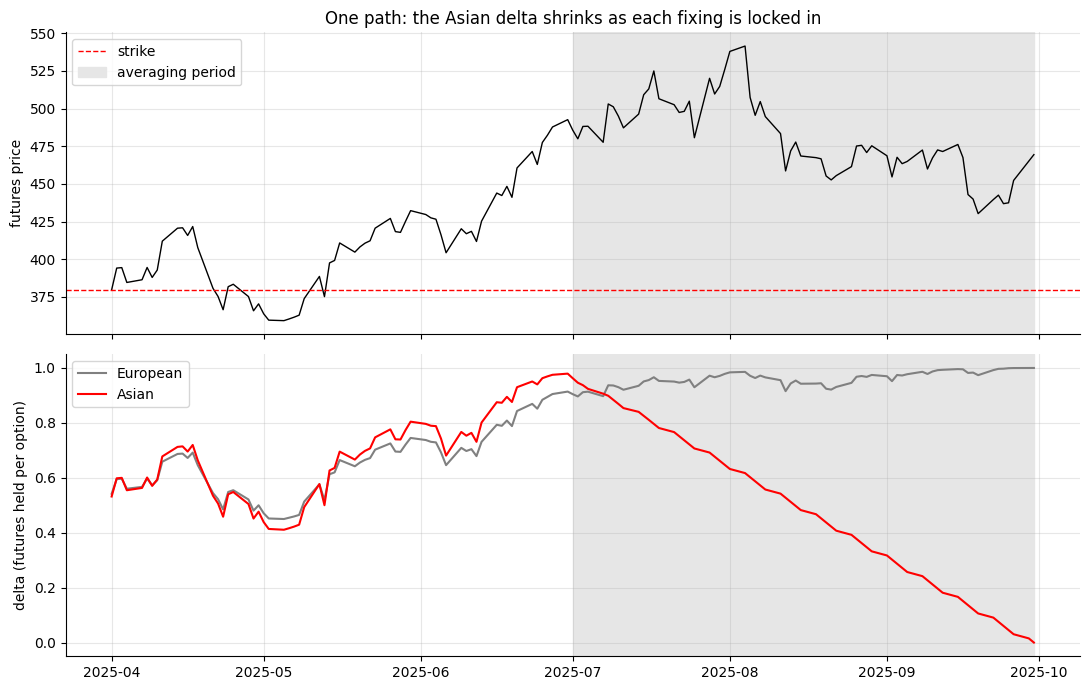

In [14]:
#delta along one path: the Asian's fades as the average locks in, the European's does not
path = hedge_paths[7]
past = 0.0
asian_d, euro_d = [], []
for k in range(len(path)):
    if k in set(fix_idx):
        past += path[k]
    asian_d.append(float(mm.price_delta(k, path[k], past)[1]))
    euro_d.append(float(european_price_delta(k, path[k], V, coffee['K'])[1]))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(dates, path, 'k-', lw=1)
axes[0].axhline(coffee['K'], color='r', ls='--', lw=1, label='strike')
axes[0].axvspan(AVG_START, EXPIRY, color='0.9', zorder=0, label='averaging period')
axes[0].set_ylabel('futures price')
axes[0].legend()
axes[1].plot(dates, euro_d, color='0.5', lw=1.5, label='European')
axes[1].plot(dates, asian_d, 'r-', lw=1.5, label='Asian')
axes[1].axvspan(AVG_START, EXPIRY, color='0.9', zorder=0)
axes[1].set_ylabel('delta (futures held per option)')
axes[1].legend()
axes[0].set_title('One path: the Asian delta shrinks as each fixing is locked in')
plt.tight_layout()
plt.show()

Inside the averaging period every passing day fixes one more of the 66 prices, so the
option is less and less exposed to where the price goes next. Its delta drains toward
zero, while a European's stays live to the last day.

A shrinking delta sounds like an easy hedge. The obvious expectation is that the Asian is
cheaper to hedge than the European. The simulation tests that rather than assuming it.

In [15]:
frequencies = [1, 2, 5, 10, 21]
results, premium, rows = {}, {}, []
for every in frequencies:
    for kind, model, payoff in [('Asian', asian_model, asian_payoff),
                                ('European', euro_model, euro_payoff)]:
        err, premium[kind] = hedging_error(hedge_paths, model, payoff, every)
        results[(kind, every)] = err
        rows.append(dict(option=kind, rebalance_every_days=every, premium=premium[kind],
                         mean_error=err.mean(), sd_error=err.std(),
                         sd_over_premium=err.std()/premium[kind],
                         worst_1pct=np.percentile(err, 1)))

summary = pd.DataFrame(rows).set_index(['option', 'rebalance_every_days']).sort_index()
summary.round(3)

premium  mean_error  sd_error  sd_over_premium  \
option   rebalance_every_days                                                   
Asian    1                      31.969       0.021     2.690            0.084   
         2                      31.969      -0.003     3.823            0.120   
         5                      31.969       0.016     6.323            0.198   
         10                     31.969       0.036     9.475            0.296   
         21                     31.969      -0.078    15.285            0.478   
European 1                      39.550       0.008     3.114            0.079   
         2                      39.550       0.006     4.361            0.110   
         5                      39.550      -0.008     6.877            0.174   
         10                     39.550       0.052     9.578            0.242   
         21                     39.550      -0.060    13.096            0.331   

                               worst_1pct  
option   rebalance_every_days              
Asian    1                         -6.889  
         2                        -10.096  
         5                        -16.646  
         10                       -25.736  
         21                       -43.383  
European 1                         -8.307  
         2                        -12.081  
         5                        -19.090  
         10                       -26.494  
         21                       -38.582

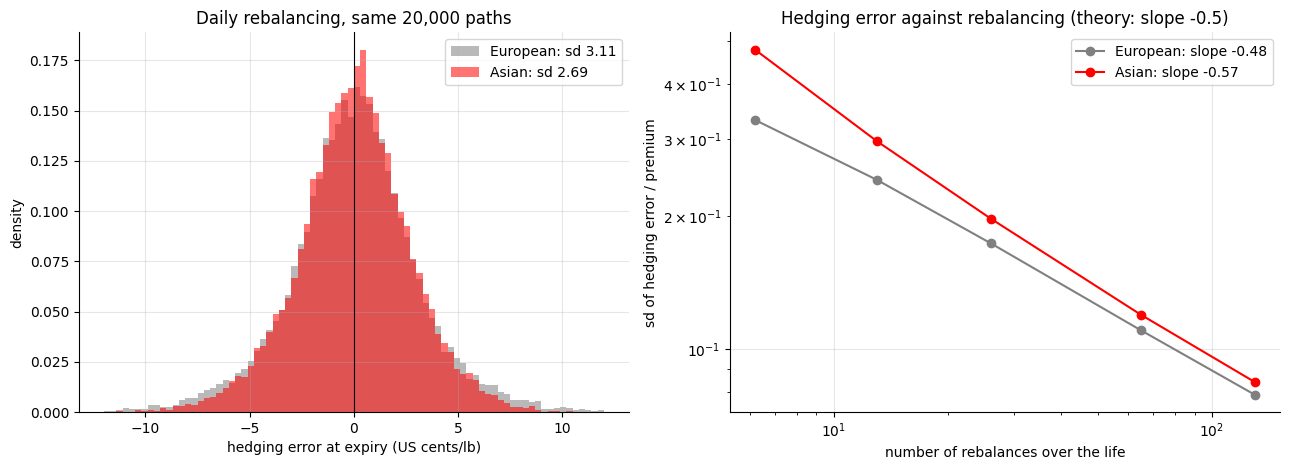

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

bins = np.linspace(-12, 12, 81)
for kind, colour in [('European', '0.5'), ('Asian', 'r')]:
    axes[0].hist(results[(kind, 1)], bins=bins, color=colour, alpha=0.55, density=True,
                 label=f'{kind}: sd {results[(kind, 1)].std():.2f}')
axes[0].axvline(0, color='k', lw=0.8)
axes[0].set_xlabel('hedging error at expiry (US cents/lb)')
axes[0].set_ylabel('density')
axes[0].set_title('Daily rebalancing, same 20,000 paths')
axes[0].legend()

#theory says the error should shrink like 1/sqrt(number of rebalances)
n_rebalances = np.array([n_steps/every for every in frequencies])
for kind, colour in [('European', '0.5'), ('Asian', 'r')]:
    sds = np.array([results[(kind, every)].std() for every in frequencies])
    slope = np.polyfit(np.log(n_rebalances), np.log(sds), 1)[0]
    axes[1].loglog(n_rebalances, sds/premium[kind], 'o-', color=colour,
                   label=f'{kind}: slope {slope:.2f}')
axes[1].set_xlabel('number of rebalances over the life')
axes[1].set_ylabel('sd of hedging error / premium')
axes[1].set_title('Hedging error against rebalancing (theory: slope -0.5)')
axes[1].legend()
plt.tight_layout()
plt.show()

**The expectation was wrong, and the reason is the interesting part.**

Rebalanced daily, the Asian's hedging error is smaller in cents than the European's, but
only by about as much as its premium is smaller - as a fraction of what was charged, the
two are about the same. And as rebalancing gets less frequent the Asian degrades *faster*
than the European.

So *when* during its life is each option hard to hedge? That can be measured directly:
rebalance daily everywhere except one month, rebalance weekly in that month, and see how
much the hedging error grows. Slide the lazy month through the option's life. Where the
error grows most is where the hedging risk lives.

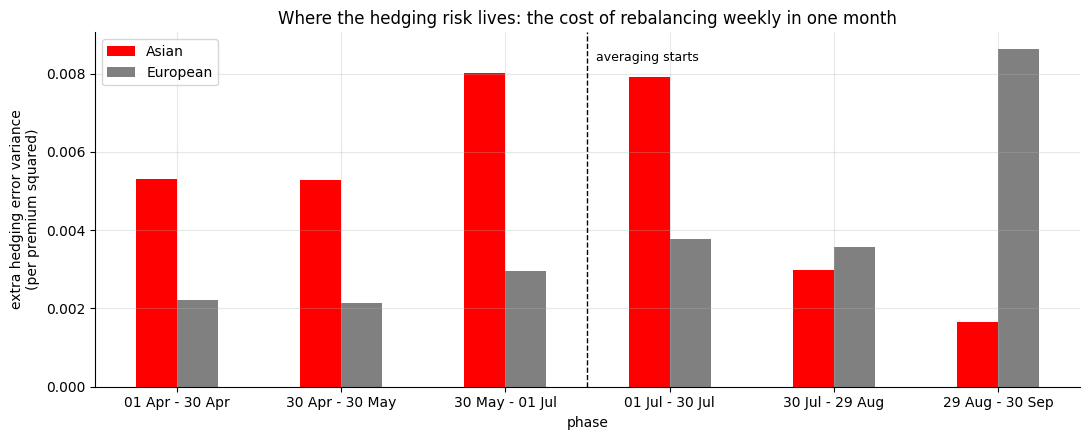

,Asian,European
phase,,
01 Apr - 30 Apr,0.0053,0.0022
30 Apr - 30 May,0.0053,0.0021
30 May - 01 Jul,0.0080,0.0030
01 Jul - 30 Jul,0.0079,0.0038
30 Jul - 29 Aug,0.0030,0.0036
29 Aug - 30 Sep,0.0017,0.0086


In [17]:
k_all = np.arange(len(dates))
weekly = k_all % 5 == 0
edges = np.linspace(0, len(dates) - 1, 7).astype(int)     # six roughly monthly phases

baseline = {}
for kind, model, payoff in [('Asian', asian_model, asian_payoff), ('European', euro_model, euro_payoff)]:
    err, prem = hedging_error(hedge_paths, model, payoff, 1)
    baseline[kind] = (err.var(), prem)

phase_rows = []
for a, b in zip(edges[:-1], edges[1:]):
    lazy_here = (k_all >= a) & (k_all < b)
    schedule = np.where(lazy_here, weekly, True)          # weekly in this phase, daily elsewhere
    row = dict(phase=f"{dates[a]:%d %b} - {dates[b]:%d %b}")
    for kind, model, payoff in [('Asian', asian_model, asian_payoff), ('European', euro_model, euro_payoff)]:
        err, prem = hedging_error(hedge_paths, model, payoff, schedule)
        row[kind] = (err.var() - baseline[kind][0])/prem**2  # extra error variance, per premium^2
    phase_rows.append(row)
phases = pd.DataFrame(phase_rows).set_index('phase')

ax = phases.plot.bar(color=['r', '0.5'], figsize=(11, 4.5), rot=0)
ax.axvline(2.5, color='k', ls='--', lw=1)
ax.text(2.55, ax.get_ylim()[1]*0.92, 'averaging starts', fontsize=9)
ax.set_ylabel('extra hedging error variance\n(per premium squared)')
ax.set_title('Where the hedging risk lives: the cost of rebalancing weekly in one month')
plt.tight_layout()
plt.show()

phases.round(4)

The two options have their hedging risk at different times:

- **The European** is hardest to hedge in its **final month**, the textbook result: at
  the money near expiry, its delta swings on small moves.
- **The Asian** is hardest to hedge in **the run-up to and the first month of the
  averaging period**, and gets steadily easier after that as fixings lock in.

The likely reason, consistent with that profile: just before averaging starts, the Asian
is an at-the-money option on a short-horizon *average*. Its price reflects a damped
volatility - averaging removes much of the risk - so its curvature relative to its
premium is high. But the futures it is hedged with still move by their full daily
volatility. The option is "low volatility"; its hedge is not. Once fixings start locking
in, the remaining exposure shrinks by one sixty-sixth a day and the problem fades.

**What it means in practice:** a desk selling average-price options should hedge most
carefully in the weeks around the start of the averaging period - which for a
quarter-average option is a predictable window, set by the contract's terms. A cheaper
average premium does not mean a proportionally cheaper hedge.

## 6. What does ignoring seasonality cost?

A neat consequence of section 4's maths: **a European option only sees the total
variance** `V(T)`. Move volatility from one month to another, keep the total, and the
European price does not change at all.

**An Asian sees when the variance arrives.** Variance during the averaging period is
partly averaged away; variance before it is not. So two volatility curves with the same
total give the same European price and *different* Asian prices.

Three volatility curves for coffee, all scaled to the same total variance:

- **flat** - one number for the whole life
- **seasonal** - the fitted monthly factors
- **seasonal + Samuelson** - adds a rise toward delivery. *This is an assumption, not a
  fit* (section 2 showed the free data cannot measure it): volatility at delivery 1.5
  times the far-from-delivery level, decaying at 3 per year.

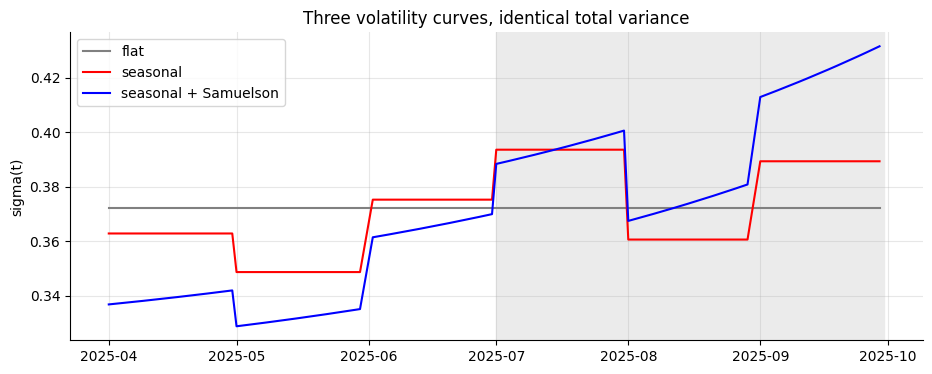

,total_variance,european,asian,asian vs flat
curve,,,,
flat,0.0714,39.5502,32.3065,0.0000
seasonal,0.0714,39.5502,31.9686,-0.0105
seasonal + Samuelson,0.0714,39.5502,30.9929,-0.0407


In [18]:
def scale_to_total(sig_curve, total):
    return sig_curve*sqrt(total/(sig_curve**2*DT).sum())

total_var = V[-1]
t_years = np.arange(n_steps)*DT
ttm = (DELIVERY['coffee'] - dates[:-1]).days.values/365
samuelson = 1.0 + 0.5*np.exp(-3.0*ttm)

curves = {
    'flat': np.full(n_steps, sqrt(total_var/T)),
    'seasonal': sig,
    'seasonal + Samuelson': scale_to_total(sig*samuelson, total_var),
}

rows = []
for label, s in curves.items():
    V_s = integrated_variance(s)
    rows.append(dict(curve=label, total_variance=V_s[-1],
                     european=black_call(coffee['F0'], coffee['K'], V_s[-1], D),
                     asian=float(MomentMatchedAsian(V_s, fix_idx, coffee['K']).price_delta(0, coffee['F0'], 0.0)[0])))
compare = pd.DataFrame(rows).set_index('curve')
compare['asian vs flat'] = compare['asian']/compare.loc['flat', 'asian'] - 1

fig, ax = plt.subplots(figsize=(11, 4))
for (label, s), colour in zip(curves.items(), ['0.5', 'r', 'b']):
    ax.plot(dates[:-1], s, color=colour, lw=1.5, label=label)
ax.axvspan(AVG_START, EXPIRY, color='0.92', zorder=0)
ax.set_ylabel('sigma(t)')
ax.set_title('Three volatility curves, identical total variance')
ax.legend()
plt.show()

compare.round(4)

Identical European prices in every row - the check that total variance really is all a
European sees. The Asian prices move, and the direction tells you where the variance sits:
variance inside the averaging period is partly averaged away, so moving variance *into*
the averaging period lowers the Asian's price, and moving it before raises it. Coffee's
seasonal curve is higher from July to September, exactly the averaging window, so the
Asian is cheaper than a flat-volatility model says. The Samuelson assumption pushes even
more variance late, toward delivery, and the gap widens.

**Model risk in the hedge.** Now hedge with the wrong model: the hedger assumes flat
volatility while the market follows the seasonal curve (and, separately, the
seasonal + Samuelson curve). The hedger charges the wrong premium and holds slightly the
wrong deltas.

In [19]:
flat_V = integrated_variance(curves['flat'])
flat_mm = MomentMatchedAsian(flat_V, fix_idx, coffee['K'])
flat_model = lambda k, F, past: flat_mm.price_delta(k, F, past)

risk_rows = []
for truth in ['seasonal', 'seasonal + Samuelson']:
    true_V = integrated_variance(curves[truth])
    true_mm = MomentMatchedAsian(true_V, fix_idx, coffee['K'])
    true_model = lambda k, F, past, m=true_mm: m.price_delta(k, F, past)
    p = simulate_paths(coffee['F0'], curves[truth], n_paths=20_000, seed=4)
    fair_premium = float(true_mm.price_delta(0, coffee['F0'], 0.0)[0])
    for hedger, model in [('right model', true_model), ('flat vol', flat_model)]:
        err, charged = hedging_error(p, model, asian_payoff, rebalance=1)
        risk_rows.append(dict(market=truth, hedger=hedger, premium_charged=charged,
                              overcharge=charged/fair_premium - 1,
                              mean_error_over_premium=err.mean()/fair_premium,
                              sd_over_premium=err.std()/fair_premium))

pd.DataFrame(risk_rows).set_index(['market', 'hedger']).round(4)

premium_charged  overcharge  \
market               hedger                                     
seasonal             right model          31.9686      0.0000   
                     flat vol             32.3065      0.0106   
seasonal + Samuelson right model          30.9929      0.0000   
                     flat vol             32.3065      0.0424   

                                  mean_error_over_premium  sd_over_premium  
market               hedger                                                 
seasonal             right model                   0.0014           0.0831  
                     flat vol                      0.0121           0.0835  
seasonal + Samuelson right model                   0.0014           0.0825  
                     flat vol                      0.0446           0.0833

The flat-volatility hedger overcharges by exactly the pricing gap - about 1% against the
seasonal market, about 4% if the Samuelson assumption holds - and so makes that much on
average. But the *spread* of the hedging error barely changes. Getting seasonality wrong
is a **pricing** problem, not a hedging problem: the hedge still works, the quote is just
off. In a competitive market that matters anyway - a dealer who prices the seasonality
quotes lower and wins the trade.

## What this notebook establishes

*All simulations are seeded, so re-running reproduces these numbers.*

**Volatility through the year**
- Softs volatility is seasonal, but modestly: roughly plus or minus 10% around an average
  month. Coffee runs hottest from July to November (frost season and the Brazilian
  harvest); sugar is quiet at the end of the year.
- The Samuelson effect cannot be measured from a continuous front-month series - it only
  ever sees contracts near delivery and jumps at every roll. It is used here only as a
  labelled assumption.
- The *level* of volatility matters far more than its seasonal shape: cocoa ran at 73%
  going into April 2025, coffee at 37%.

**Pricing - every number checked against another**
- The simulated geometric Asian lands within 0.3 standard errors of its exact price.
- The geometric control variate cuts Monte Carlo variance by roughly 1,100x (cocoa) to
  7,200x (sugar) - the same accuracy from a thousandth of the paths.
- Moment matching agrees with Monte Carlo to within about 0.2%, and its delta matches a
  bumped Monte Carlo delta to the third decimal.
- The quarter-average Asian costs about 81% of the matching European.

**Hedging**
- Rebalanced daily, the hedging error is about 8% of the premium for both options.
- Rebalanced less often, the Asian degrades faster than the European.
- The two have their hedging risk at different times: the European in its final month,
  the Asian around the start of its averaging period. The cheaper premium does not buy a
  proportionally easier hedge.

**Seasonality**
- With total variance held fixed, the European price does not move at all; the Asian
  moves by about 1% (fitted seasonality) to 4% (with the Samuelson assumption).
- Ignoring seasonality misprices the Asian but leaves the hedge's reliability intact.

**Limitations, stated once**
- Volatility is historical, not implied: free implied vols for softs are not available.
- The front-month price stands in for the deferred contract on the writing date.
- Futures follow a lognormal model with no jumps; transaction costs are ignored, which
  flatters frequent rebalancing.

**Next:** the Večeř PDE reduction as a third, independent price for the Asian (stretch),
and `options_02_set50.ipynb` for the Bangkok comparison.